# Prescient Coding Challenge 2026 — Backtest Harness

Notebook version of `harness.py`, split into cells for interactive exploration.

**This notebook is for your own exploration only.** The official harness is `harness.py` and must not be edited — your submission is `solution.py` and nothing else (edits to `harness.py` are a disqualification, since it's diffed). Use this notebook to poke at `History`, run backtests interactively, and plot results; don't treat it as a replacement submission artifact.

The harness owns the walk-forward loop. On each rebalance date it hands your `generate_weights()` function a `History` object containing only data strictly before that date, takes the weights you return, charges trading costs, checks the constraints, and accumulates the portfolio return.

## Imports

In [58]:
from __future__ import annotations

import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd

## Problem definition

These are the rules, in code: assets, benchmark weights, active-weight bands/budget, equity/gold caps, trading costs, covariance estimator settings, and evaluation windows.

In [59]:
# --------------------------------------------------------------------------- #
# problem definition -- these are the rules, in code
# --------------------------------------------------------------------------- #

ASSETS: list[str] = [
    "SA_EQUITY",      # FTSE/JSE All Share, total return, ZAR
    "GLOBAL_EQUITY",  # MSCI World net total return, converted to ZAR
    "SA_BONDS",       # FTSE/JSE All Bond Index, total return
    "SA_CASH",        # STeFI Composite
    "SA_PROPERTY",    # FTSE/JSE SA Listed Property, total return
    "GOLD",           # gold spot per oz, converted to ZAR
]

# The benchmark: a fixed-weight South African balanced fund, rebalanced daily
# at zero cost (it is an index, not a portfolio).
BENCHMARK: dict[str, float] = {
    "SA_EQUITY":     0.400,
    "GLOBAL_EQUITY": 0.200,
    "SA_BONDS":      0.250,
    "SA_CASH":       0.075,
    "SA_PROPERTY":   0.050,
    "GOLD":          0.025,
}

# How far any single asset may sit from its benchmark weight.
ACTIVE_BAND: float = 0.10

# How much active weight you may run in total: sum over assets of
# |weight - benchmark weight|. This is your risk budget.
ACTIVE_BUDGET: float = 0.40

# Minimum average total active weight over an evaluation window. A portfolio
# that never leaves the benchmark is not an answer to the question.
MIN_ACTIVE_WEIGHT: float = 0.05

# Hard cap on total equity, whatever the bands and budget allow. A balanced
# fund is not a balanced fund at 80% equity, and the 40% active budget makes
# that reachable.
EQUITY: list[str] = ["SA_EQUITY", "GLOBAL_EQUITY"]
EQUITY_CAP: float = 0.75

# Hard cap on commodity exposure, whatever the band allows.
GOLD_CAP: float = 0.10

TRADING_DAYS: int = 252

# One-way trading cost in basis points of the traded amount.
COSTS_BPS: dict[str, float] = {
    "SA_EQUITY":     15.0,
    "GLOBAL_EQUITY": 20.0,
    "SA_BONDS":       8.0,
    "SA_CASH":        1.0,
    "SA_PROPERTY":   35.0,
    "GOLD":          25.0,
}

# Covariance estimator offered to you as an optional tool via hist.cov() and
# hist.te(). Nothing in the rules depends on it -- use it only if you want to.
COV_WINDOW: int = 250
COV_LAMBDA: float = 0.97

# Evaluation windows.
PRACTICE_WINDOW = (dt.date(2025, 1, 2), dt.date(2025, 12, 31))
ROBUSTNESS_WINDOWS = {
    "2015": (dt.date(2015, 1, 2), dt.date(2015, 12, 31)),   # ZAR shock
    "2016": (dt.date(2016, 1, 4), dt.date(2016, 12, 30)),   # post-Nenegate, commodity rebound
    "2020": (dt.date(2020, 1, 2), dt.date(2020, 12, 31)),   # covid
    "2022": (dt.date(2022, 1, 3), dt.date(2022, 12, 31)),   # inflation shock
}

_TOL = 1e-6
DATA_DIR = Path.cwd() / "data"  # notebooks have no __file__; assumes notebook runs from the project root

## `History` — the object your function receives

Everything knowable strictly before the decision date, plus the optional `cov()` / `te()` helpers.

In [60]:
class History:
    """Everything knowable strictly before the decision date.

    Attributes
    ----------
    date : datetime.date
        The date you are setting weights for. Your weights earn this day's
        return. You do not have this day's data.
    returns : pandas.DataFrame
        Daily total returns as decimals (0.01 == 1 percent), indexed by date,
        one column per asset in ASSETS order. The last row is the previous
        trading day.
    prices : pandas.DataFrame
        Total-return index levels, same shape as returns.
    macro : pandas.DataFrame
        Macro features, indexed by date.
    benchmark : pandas.Series
        The benchmark weights, in ASSETS order.
    """

    def __init__(self, date, returns, prices, macro):
        self.date = date
        self.returns = returns
        self.prices = prices
        self.macro = macro
        self.assets = list(ASSETS)
        self.benchmark = pd.Series(BENCHMARK)[ASSETS]
        self._cov_cache = None

    def active_weight(self, weights) -> float:
        """Total absolute active weight: sum of |weight - benchmark weight|.

        This is the number rule 3 tests against ACTIVE_BUDGET.
        """
        w = _as_vector(weights)
        return float(np.abs(w - self.benchmark.to_numpy()).sum())

    # ---- optional extras. No rule depends on these. ---- #

    def cov(self) -> pd.DataFrame:
        """Annualised EWMA covariance matrix of asset returns, as at date.

        Optional. Offered in case you want to reason about risk rather than
        just weights; nothing in the rules requires it.
        """
        if self._cov_cache is None:
            window = self.returns.tail(COV_WINDOW)
            if len(window) < 20:
                raise RuntimeError("not enough history to estimate covariance")
            x = window.to_numpy(dtype=float)
            x = x - x.mean(axis=0)
            w = COV_LAMBDA ** np.arange(len(x) - 1, -1, -1)
            w = w / w.sum()
            cov = (x * w[:, None]).T @ x * TRADING_DAYS
            self._cov_cache = pd.DataFrame(
                cov, index=self.returns.columns, columns=self.returns.columns)
        return self._cov_cache

    def te(self, weights) -> float:
        """Ex-ante annualised tracking error of weights versus the benchmark.

        Optional, and reported in the results for interest. No rule uses it.
        """
        active = _as_vector(weights) - self.benchmark.to_numpy()
        return float(np.sqrt(max(float(active @ self.cov().to_numpy() @ active), 0.0)))


def _as_vector(weights) -> np.ndarray:
    """Coerce a dict / Series / array of weights into ASSETS order."""
    if isinstance(weights, pd.Series):
        out = weights.reindex(ASSETS)
        if out.isna().any():
            missing = sorted(set(ASSETS) - set(weights.index))
            raise ValueError(f"generate_weights() returned no weight for: {missing}")
        return out.to_numpy(dtype=float)
    if isinstance(weights, dict):
        missing = sorted(set(ASSETS) - set(weights))
        if missing:
            raise ValueError(f"generate_weights() returned no weight for: {missing}")
        return np.array([float(weights[a]) for a in ASSETS])
    arr = np.asarray(weights, dtype=float).ravel()
    if arr.size != len(ASSETS):
        raise ValueError(f"expected {len(ASSETS)} weights, got {arr.size}")
    return arr

## Data loading

In [61]:
def load_data(data_dir: Path | str = DATA_DIR):
    """Load the asset and macro files. Returns (returns, prices, macro)."""
    data_dir = Path(data_dir)
    assets = pd.read_csv(data_dir / "data_assets.csv", parse_dates=["datestamp"])
    macro = pd.read_csv(data_dir / "data_macro.csv", parse_dates=["datestamp"])

    returns = assets.pivot(index="datestamp", columns="asset_code", values="return")[ASSETS]
    prices = assets.pivot(index="datestamp", columns="asset_code", values="price")[ASSETS]
    macro = macro.set_index("datestamp").sort_index()
    print("done")
    return returns.sort_index(), prices.sort_index(), macro

## Constraint checking

In [62]:
# --------------------------------------------------------------------------- #
# constraint checking
# --------------------------------------------------------------------------- #

def check_weights(weights: np.ndarray, hist: History) -> list[str]:
    """Return a list of constraint breaches (empty list means feasible)."""
    problems: list[str] = []

    if not np.isfinite(weights).all():
        return ["weights contain NaN or inf"]

    w = pd.Series(weights, index=ASSETS)
    bm = pd.Series(BENCHMARK)[ASSETS]
    active = w - bm

    if abs(w.sum() - 1.0) > 1e-4:
        problems.append(f"weights sum to {w.sum():.6f}, must sum to 1")

    for asset in ASSETS:
        if w[asset] < -_TOL:
            problems.append(f"{asset} weight {w[asset]:.4f} is negative")

    for asset in ASSETS:
        if abs(active[asset]) > ACTIVE_BAND + _TOL:
            problems.append(
                f"{asset} is {active[asset]:+.2%} away from its benchmark weight, "
                f"outside the +/-{ACTIVE_BAND:.0%} band")

    total = active.abs().sum()
    if total > ACTIVE_BUDGET + _TOL:
        problems.append(
            f"total active weight {total:.2%} above the {ACTIVE_BUDGET:.0%} budget")

    equity = w[EQUITY].sum()
    if equity > EQUITY_CAP + _TOL:
        problems.append(
            f"total equity {equity:.2%} above the {EQUITY_CAP:.0%} cap")

    if w["GOLD"] > GOLD_CAP + _TOL:
        problems.append(f"GOLD weight {w['GOLD']:.2%} above its {GOLD_CAP:.0%} cap")

    return problems

## The walk-forward loop

In [63]:
# --------------------------------------------------------------------------- #
# the walk-forward loop
# --------------------------------------------------------------------------- #

def run_backtest(generate_weights, params, start, end, data=None, verbose=True,
                 on_breach="raise"):
    """Walk forward from start to end, calling generate_weights each day.

    Parameters
    ----------
    generate_weights : callable
        Your function: generate_weights(hist, prev_weights, params) -> weights.
    params : dict
        Passed straight through to your function.
    start, end : datetime.date
        Inclusive bounds of the evaluation window.
    data : tuple, optional
        (returns, prices, macro). Loaded from ./data if omitted.

    Returns
    -------
    pandas.DataFrame
        One row per evaluation date with portfolio return, benchmark return,
        cost, turnover, active weight and cumulative index levels.
    """
    returns, prices, macro = data if data is not None else load_data()

    start_ts, end_ts = pd.Timestamp(start), pd.Timestamp(end)
    dates = returns.index[(returns.index >= start_ts) & (returns.index <= end_ts)]
    if len(dates) == 0:
        raise ValueError(f"no trading days between {start} and {end}")

    bm = pd.Series(BENCHMARK)[ASSETS].to_numpy()
    cost_vec = np.array([COSTS_BPS[a] for a in ASSETS]) / 10_000.0

    if on_breach not in ("raise", "benchmark"):
        raise ValueError("on_breach must be 'raise' or 'benchmark'")

    prev = bm.copy()          # you start the window holding the benchmark
    breaches: list[str] = []
    rows = []

    for date in dates:
        hist = History(
            date=date.date(),
            returns=returns[returns.index < date],
            prices=prices[prices.index < date],
            macro=macro[macro.index < date],
        )

        weights = _as_vector(generate_weights(hist, pd.Series(prev, index=ASSETS), params))

        problems = check_weights(weights, hist)
        if problems:
            breaches.append(f"{date.date()}: " + "; ".join(problems))
            if on_breach == "benchmark":
                # Grading mode. Rather than void the whole window, hold the
                # benchmark for the day: the team forfeits any view they had,
                # which is a real cost and cannot be gamed into an advantage,
                # but one bad day no longer zeroes an entire submission.
                weights = bm.copy()

        traded = np.abs(weights - prev)
        cost = float(traded @ cost_vec)
        realised = returns.loc[date].to_numpy(dtype=float)
        gross = float(weights @ realised)

        rows.append({
            "datestamp": date,
            "port_return_gross": gross,
            "cost": cost,
            "port_return": gross - cost,
            "bm_return": float(bm @ realised),
            "turnover": float(traded.sum() / 2.0),
            "active_weight": float(np.abs(weights - bm).sum()),
            "ex_ante_te": hist.te(weights),      # informational only
            **{f"w_{a}": weights[i] for i, a in enumerate(ASSETS)},
        })
        prev = weights

    if breaches and on_breach == "raise":
        head = "\n  ".join(breaches[:15])
        more = f"\n  ... and {len(breaches) - 15} more" if len(breaches) > 15 else ""
        raise ValueError(f"Constraint breaches on {len(breaches)} day(s):\n  {head}{more}")

    out = pd.DataFrame(rows).set_index("datestamp")
    out.attrs["violations"] = len(breaches)
    out.attrs["first_violations"] = breaches[:5]
    out["active_return"] = out["port_return"] - out["bm_return"]
    out["port_tri"] = (1 + out["port_return"]).cumprod()
    out["bm_tri"] = (1 + out["bm_return"]).cumprod()

    mean_active = out["active_weight"].mean()
    out.attrs["mean_active"] = float(mean_active)
    if mean_active < MIN_ACTIVE_WEIGHT:
        raise ValueError(
            f"Average total active weight over this window was {mean_active:.2%}, below "
            f"the {MIN_ACTIVE_WEIGHT:.0%} minimum. Your portfolio barely leaves the "
            f"benchmark -- take a view."
        )

    if verbose:
        print(summarise(out))
    return out

## Summary and scoring metrics

In [64]:
def summarise(bt: pd.DataFrame) -> str:
    """Human-readable performance summary of a backtest frame."""
    n = len(bt)
    # cumulative over the window, not annualised: windows are under a year
    port = bt["port_tri"].iloc[-1] - 1
    bench = bt["bm_tri"].iloc[-1] - 1
    active = bt["active_return"]
    ir = active.mean() / active.std() * np.sqrt(TRADING_DAYS) if active.std() > 0 else 0.0
    dd = (bt["port_tri"] / bt["port_tri"].cummax() - 1).min()

    return "\n".join([
        f"---> window            {bt.index[0].date()} to {bt.index[-1].date()}  ({n} days)",
        f"---> portfolio  (net)  {100 * port:7.2f}%  cumulative",
        f"---> benchmark         {100 * bench:7.2f}%  cumulative",
        f"---> excess     (net)  {100 * (bt['port_tri'].iloc[-1] - bt['bm_tri'].iloc[-1]):7.2f}%  cumulative",
        f"---> excess (scored)   {1e4 * (bt['port_tri'].iloc[-1] ** (1 / n) - bt['bm_tri'].iloc[-1] ** (1 / n)):7.3f}   bps/day",
        f"---> information ratio {ir:7.2f}",
        f"---> active weight     {100 * bt['active_weight'].mean():7.2f}% average, "
        f"{100 * bt['active_weight'].max():.2f}% peak (budget {100 * ACTIVE_BUDGET:.0f}%)",
        f"---> cost drag         {100 * bt['cost'].sum():7.2f}%   avg daily turnover "
        f"{100 * bt['turnover'].mean():.2f}%",
        f"---> max drawdown      {100 * dd:7.2f}%",
    ])


def metrics(bt: pd.DataFrame) -> dict:
    """Scoring metrics for one window."""
    active = bt["active_return"]
    n = len(bt)
    return {
        "days": n,
        "port_return": bt["port_tri"].iloc[-1] - 1,
        "bm_return": bt["bm_tri"].iloc[-1] - 1,
        "excess_return": bt["port_tri"].iloc[-1] - bt["bm_tri"].iloc[-1],
        # Scoring metric: mean net excess return PER DAY, in basis points.
        # Deliberately not annualised -- the live window is under a year, and
        # annualising a sub-year return overstates it. A per-day rate is
        # horizon-free, so a 160-day window and a 250-day one are directly
        # comparable, and within a window it ranks identically to cumulative
        # return because x ** (1/n) is monotone.
        "daily_excess_bps": 1e4 * (bt["port_tri"].iloc[-1] ** (1 / n)
                                   - bt["bm_tri"].iloc[-1] ** (1 / n)),
        "information_ratio": (active.mean() / active.std() * np.sqrt(TRADING_DAYS)
                              if active.std() > 0 else 0.0),
        "realised_te": active.std() * np.sqrt(TRADING_DAYS),
        "mean_active_weight": bt["active_weight"].mean(),
        "max_active_weight": bt["active_weight"].max(),
        "max_exante_te": bt["ex_ante_te"].max(),
        "cost_drag": bt["cost"].sum(),
        "avg_turnover": bt["turnover"].mean(),
        "max_drawdown": (bt["port_tri"] / bt["port_tri"].cummax() - 1).min(),
    }

## Plotting

In [65]:
def plot_result(bt: pd.DataFrame) -> None:
    """Total-return and weight charts. Requires plotly; skipped if absent."""
    try:
        import plotly.express as px
    except ImportError:
        print("---> plotly not installed, skipping charts "
              "(pip install -r requirements.txt)")
        return

    tri = bt[["port_tri", "bm_tri"]].rename(
        columns={"port_tri": "your portfolio", "bm_tri": "benchmark"})
    px.line(tri, title="Total return: portfolio vs benchmark").show()

    wcols = [f"w_{a}" for a in ASSETS]
    weights = bt[wcols].rename(columns={f"w_{a}": a for a in ASSETS})
    px.area(weights, title="Portfolio weights through time").show()

    px.line(bt[["active_weight"]].rename(columns={"active_weight": "total active weight"}),
            title=f"Total active weight (budget {ACTIVE_BUDGET:.0%})").show()

## Run it

Equivalent to running `python harness.py`, adapted for notebook use: import your `solution.py`, run the practice-window backtest, and plot the results.

---> Prescient Coding Challenge 2026 -- practice window
done
---> window            2025-01-02 to 2025-12-31  (250 days)
---> portfolio  (net)    24.86%  cumulative
---> benchmark           27.23%  cumulative
---> excess     (net)    -2.37%  cumulative
---> excess (scored)    -0.754   bps/day
---> information ratio   -2.59
---> active weight       19.28% average, 20.00% peak (budget 40%)
---> cost drag            0.02%   avg daily turnover 0.04%
---> max drawdown        -5.48%
---> declared parameters: 3
---> run time 0:00:06.529566


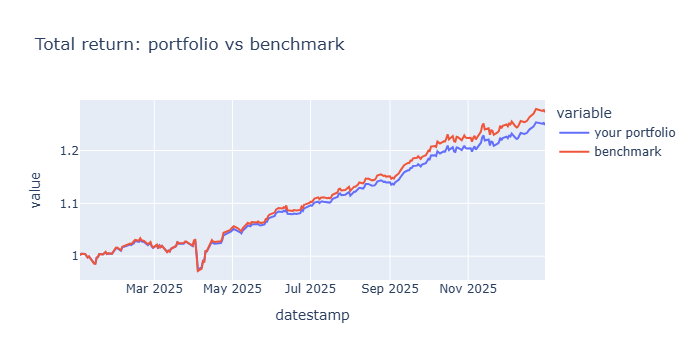

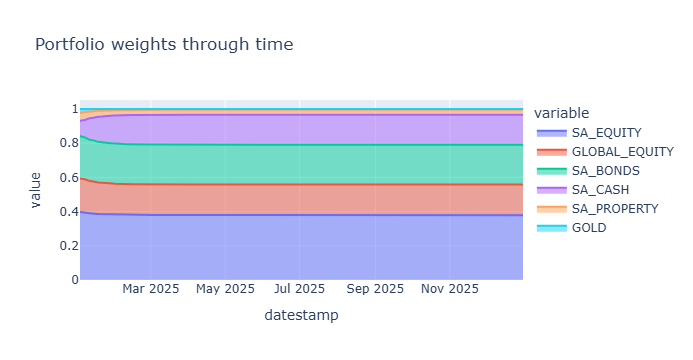

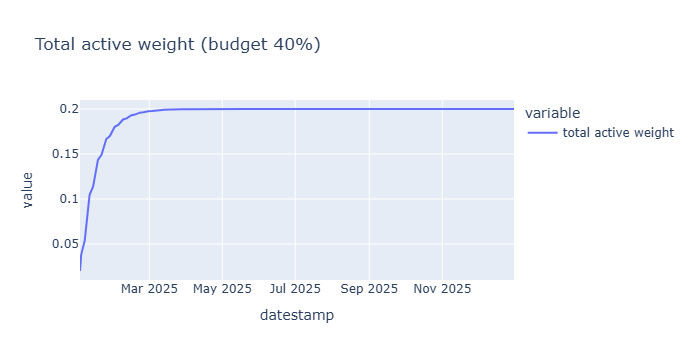

In [66]:
import solution

t0 = dt.datetime.now()
print("---> Prescient Coding Challenge 2026 -- practice window")
result = run_backtest(
    solution.generate_weights, solution.PARAMS,
    start=PRACTICE_WINDOW[0], end=PRACTICE_WINDOW[1],
)
print(f"---> declared parameters: {len(solution.PARAMS)}")
print(f"---> run time {dt.datetime.now() - t0}")
plot_result(result)